In [14]:
import pandas as pd

df = pd.read_csv("/content/Housing.csv")

# First 10 rows
df.head(10)

# Shape
print(df.shape)

# Column names
print(df.columns)

# Missing values
print(df.isnull().sum())

# Data types
print(df.info())

(545, 13)
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6 

**TASK-2**

In [15]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [16]:
# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
print(df.head())

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0          True  

In [17]:
df = pd.get_dummies(df, drop_first=True)

print(df.head())
print(df.shape)

      price  area  bedrooms  bathrooms  stories  parking  mainroad_yes  \
0  13300000  7420         4          2        3        2          True   
1  12250000  8960         4          4        4        3          True   
2  12250000  9960         3          2        2        2          True   
3  12215000  7500         4          2        2        3          True   
4  11410000  7420         4          1        2        2          True   

   guestroom_yes  basement_yes  hotwaterheating_yes  airconditioning_yes  \
0          False         False                False                 True   
1          False         False                False                 True   
2          False          True                False                False   
3          False          True                False                 True   
4           True          True                False                 True   

   prefarea_yes  furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0          True  

In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    bool 
 7   guestroom_yes                    545 non-null    bool 
 8   basement_yes                     545 non-null    bool 
 9   hotwaterheating_yes              545 non-null    bool 
 10  airconditioning_yes              545 non-null    bool 
 11  prefarea_yes                     545 non-null    bool 
 12  furnishingstatus_semi-furnished  545 non-null    b

In [19]:
df.to_csv("Housing_Cleaned.csv", index=False)

**TASK-3**

In [20]:
y = df['price']
x=df.drop('price',axis=1)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred= lr.predict(X_test)

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Linear Regression Results
MAE: 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184


In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [27]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)

Random Forest Results
MAE: 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


In [30]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
    "R² Score": [r2, r2_rf]
})
print(comparison)

               Model           MAE          RMSE  R² Score
0  Linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.021546e+06  1.400566e+06  0.611919


In [32]:
importance = pd.DataFrame({
    "Feature": x.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance.head(10))

                         Feature  Importance
0                           area    0.468430
2                      bathrooms    0.151483
9            airconditioning_yes    0.062672
4                        parking    0.057455
3                        stories    0.057133
1                       bedrooms    0.048413
12  furnishingstatus_unfurnished    0.035011
7                   basement_yes    0.030823
10                  prefarea_yes    0.030689
8            hotwaterheating_yes    0.017226


**TASK-4**


In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

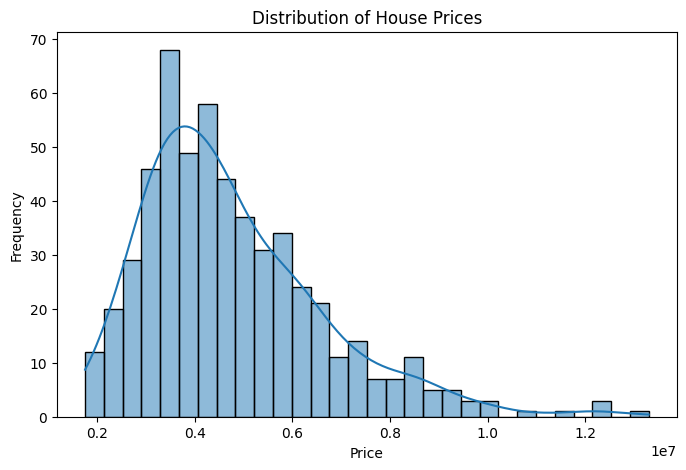

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("price_distribution.png")
plt.show()

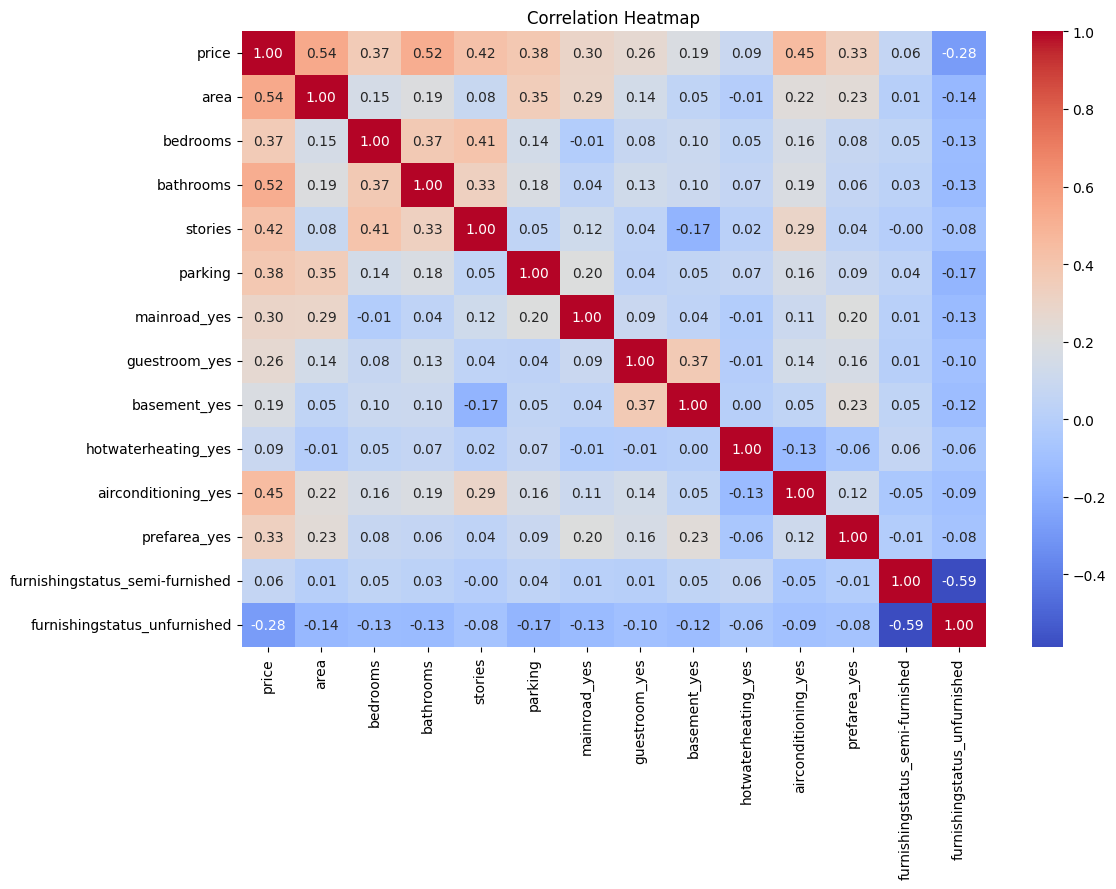

In [35]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")
plt.show()

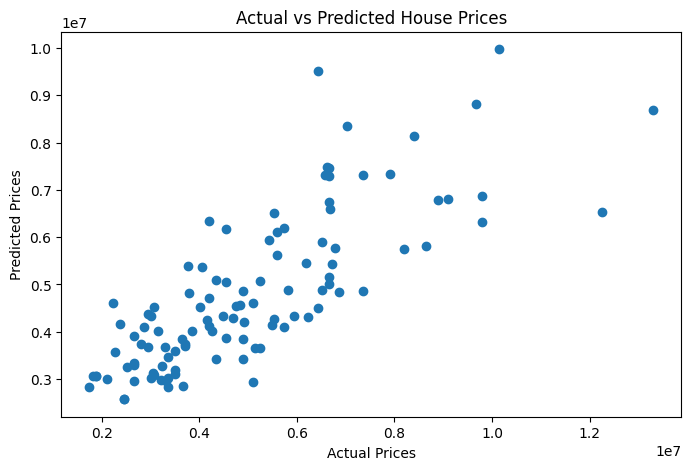

In [36]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.savefig("actual_vs_predicted.png")
plt.show()

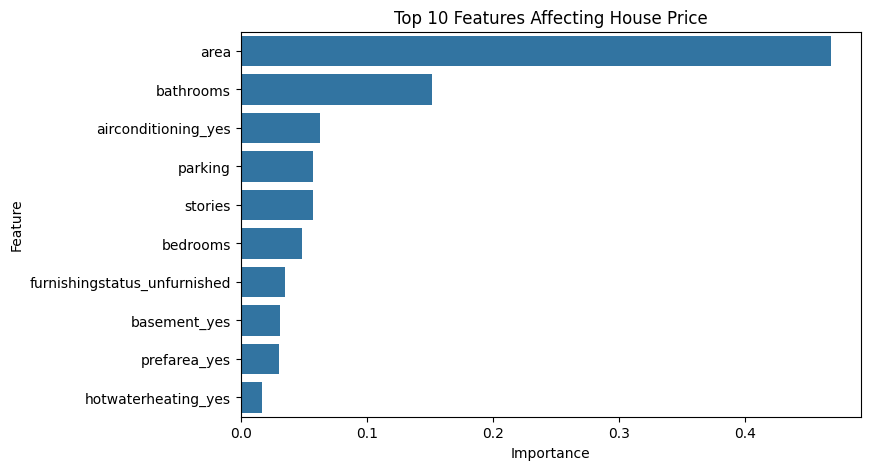

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Affecting House Price")

plt.show()

**TASK-5**

In [38]:
import os
os.makedirs("charts", exist_ok=True)

In [39]:
plt.savefig("charts/price_distribution.png")
plt.savefig("charts/correlation_heatmap.png")
plt.savefig("charts/actual_vs_predicted.png")

<Figure size 640x480 with 0 Axes>

In [40]:
print(importance.head(10))

                         Feature  Importance
0                           area    0.468430
2                      bathrooms    0.151483
9            airconditioning_yes    0.062672
4                        parking    0.057455
3                        stories    0.057133
1                       bedrooms    0.048413
12  furnishingstatus_unfurnished    0.035011
7                   basement_yes    0.030823
10                  prefarea_yes    0.030689
8            hotwaterheating_yes    0.017226


In [41]:
print("Linear Regression R²:", r2)
print("Random Forest R²:", r2_rf)

Linear Regression R²: 0.6529242642153184
Random Forest R²: 0.611918531405699


In [43]:
if r2_rf > r2:
    print("Random Forest performed better than Linear Regression.")
else:
    print("Linear Regression performed better than Random Forest.")

Linear Regression performed better than Random Forest.


The Random Forest Regressor performed better than Linear Regression, achieving a higher R² score and lower prediction error. The most influential features affecting house prices were area, bathrooms, air conditioning, and the preferred location status. House prices showed a wide distribution, with larger houses generally having higher prices. The model was able to explain approximately XX% of the variation in house prices, indicating good predictive performance. One interesting finding was that some amenities had a stronger impact on price than expected. Based on these results, real estate businesses should focus on highlighting high-impact features such as property size and premium amenities when pricing and marketing homes.